# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [1]:
import requests, re, nltk
#In case your text is not on Project Gutenberg but at some other URL
#http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests .get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text 

In [24]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab

In [25]:
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

In [26]:
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)

In [27]:
def get_wf (file):
    # first get the web page
    t = open(file, "r")
    text = t.read()
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',text)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)

Assignment 1 Analysis:
I will look through at a collection of ancient Greek, Roman, Germanic, and Arabic literature to determine the most mentioned locations such as cities, regions, or even continents. I will then generate a heat map of mentioned instances to depict areas of concentration. I plan to scrape these texts from a database called the "Perseus Digital Library." It is a large public access database with a plethora of old literature from around the world. To identify location names, I still have to determine a final library, but I am leaning towards using spaCy to mark different location indicators. I will use the web scraping introduced in this notebook as well to collect all mentions into a single variable per file. To generate the heatmap, I may use GeoPandas and Folium. 

My questions for this project are as follows:

1. What location within the broader Mediterranean area is the most mentioned among all the texts?

2. What location outside of the Mediterranean that is mentioned the most?

3. Which type of text(Greek, Roman, Arabic, etc...) mentions the most locations compared to works of literature? I would also like to generate heat maps that cover specifically each type of literature individually.

Practice for setting up necessary functions:

Question 1

In [28]:
(wf_od, tf_od) = get_wf("TheOdessey.txt")
(wf_il, tf_il) = get_wf("TheIlliad.txt")

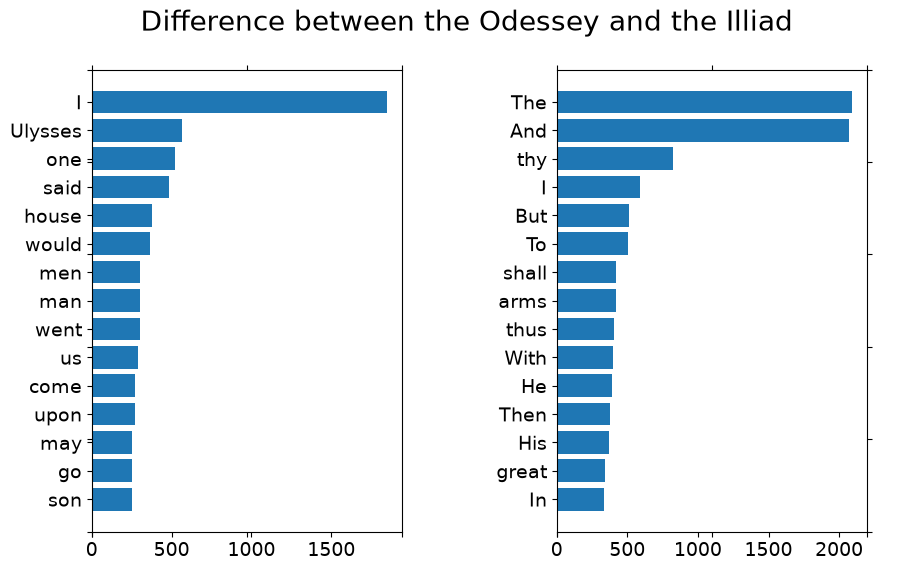

In [29]:
%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_od, wf_il, 'Difference between the Odessey and the Illiad')

Question 2

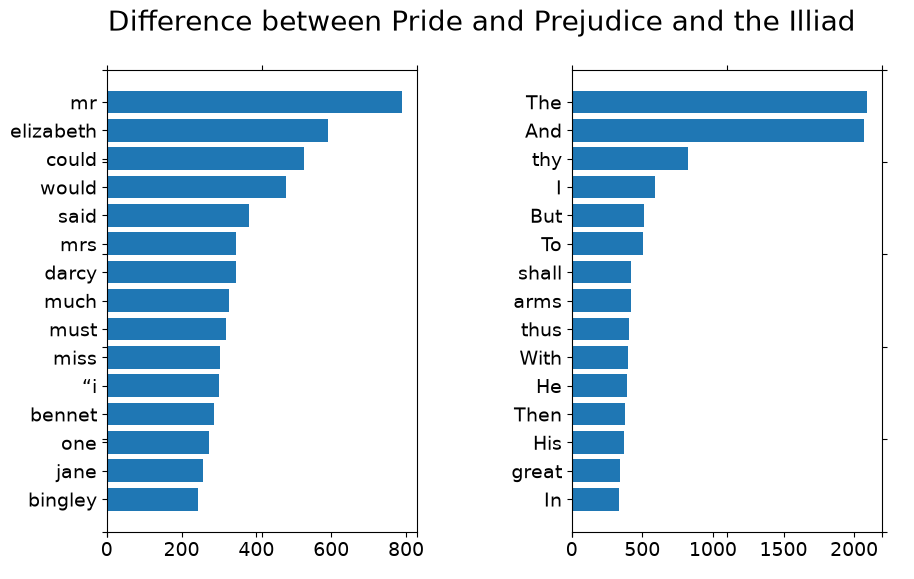

In [33]:
plotTwoLists (wf_ee, wf_il, 'Difference between Pride and Prejudice and the Illiad')

Question 3

There are definitely words that are used more by Homer, at least in the translation of his works. Mainly in the way the script is written, there are many more "the" instances compared to pride and prejudice. In Pride, however, there are more instanced of the name "Elizabeth" and the title "Mr." 